# 問題
ロジスティック回帰モデルを学習するとき、正則化の係数（ハイパーパラメータ）を調整することで、学習時の適合度合いを制御できる。正則化の係数を変化させながらロジスティック回帰モデルを学習し、検証データ上の正解率を求めよ。実験の結果は、正則化パラメータを横軸、正解率を縦軸としたグラフにまとめよ。

In [1]:
import spacy
from collections import Counter

# --- pathの準備 ---
path_dev = "./SST-2/dev.tsv"
path_train = "./SST-2/train.tsv"

# --- 形態素解析の準備 ---
nlp = spacy.load("en_core_web_sm")

def integrate_dict(path):
    final_list = []
    with open(path, 'r', encoding='utf-8') as f:
        for row in f:
            row = row.strip().split("\t")
            if not row:
                continue
            if row[1] == "0" or row[1] == "1":
                text = row[0]
                word_counter = Counter()
                doc = nlp(text)
                for tok in doc:
                    # 追加: 軽い前処理（英字のみ＋小文字化）
                    if tok.is_alpha:
                        word_counter.update([tok.text.lower()])
                        tmp_dict = {
                            "text": row[0],
                            "label": row[1],
                            "feature": dict(word_counter),
                        }
                        final_list.append(tmp_dict)
            else:
                print("0と1以外です：", row[1])
    return final_list

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# データ作成
train_items = integrate_dict(path_train)
dev_items   = integrate_dict(path_dev)

X_train_dicts = [d["feature"] for d in train_items]
y_train = np.array([int(d["label"]) for d in train_items])

X_dev_dicts = [d["feature"] for d in dev_items]
y_dev = np.array([int(d["label"]) for d in dev_items])

# 辞書 → 疎行列
vec = DictVectorizer(sparse=True)
X_train = vec.fit_transform(X_train_dicts)
X_dev   = vec.transform(X_dev_dicts)

# 学習（ロジスティック回帰）
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

0と1以外です： label
0と1以外です： label


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


Best C on dev = 0.20691, accuracy = 0.7370


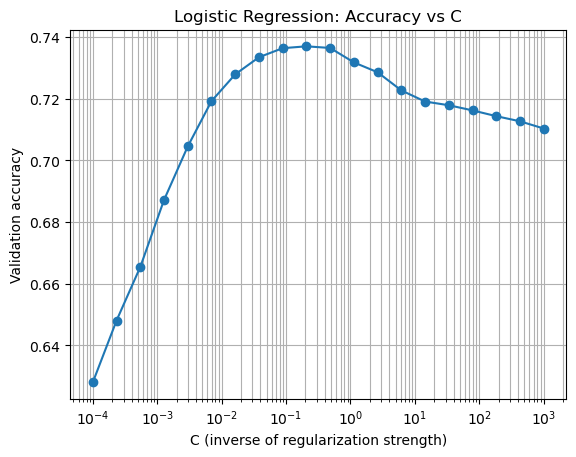

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 例: C を対数スケールで広く探索（必要に応じて範囲/刻みは調整）
Cs = np.logspace(-4, 3, 20)  # 1e-4 ～ 1e3 の 20 点

dev_accs = []

for C in Cs:
    clf = LogisticRegression(
        penalty="l2",        # L2 正則化（標準）
        C=C,                 # 正則化の強さの逆数（大きいほど弱い）
        solver="liblinear",  # 疎行列でも安定。多クラスは 'saga' も可
        max_iter=1000,
        n_jobs=None          # liblinear では無視されます
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_dev)
    acc = accuracy_score(y_dev, y_pred)
    dev_accs.append(acc)

# 結果表示
best_idx = int(np.argmax(dev_accs))
best_C = Cs[best_idx]
best_acc = dev_accs[best_idx]
print(f"Best C on dev = {best_C:.5g}, accuracy = {best_acc:.4f}")

# グラフ化（単一プロット・色指定なし）
plt.figure()
plt.semilogx(Cs, dev_accs, marker="o")
plt.xlabel("C (inverse of regularization strength)")
plt.ylabel("Validation accuracy")
plt.title("Logistic Regression: Accuracy vs C")
plt.grid(True, which="both")
plt.show()